<a href="https://colab.research.google.com/github/Darwinfcc/TFM-Radiaci-n-Difusa/blob/main/TFM_Radiaci%C3%B3n_Difusa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Código de programación Modelado y predicción de la radiación difusa en Ecuador mediante modelos de aprendizaje profundo (N-BEATS y LSTM)

## Instalación y configuración del entorno



En el TFM las librerías a utilizar son: pandas y Numpy para la manipulación, limpieza y estructuración de los datos, lo que permitirá trabajar de mejor manera con la cantidad de información obtenida del repositorio de información de POWER NASA.

* Para la visualización de datos se utilizará Matplotlib, Seaborn y Plotly mismas que facilitarán la representación gráfica de patrones, tendencias y relaciones dentro del conjunto de datos.

* Para el proceso de minerías de datos y aprendizaje automático, se empleará scikit-learn para la selección de variables, evaluación de modelos y cálculos de métricas de desempeño.

* Para el análisis de series temporales se empleará statsmodels en el modelo SARIMAX que permitirá capturar componentes estacionales y exógenos en los datos.

* En cuanto a técnicas de aprendizaje profundo, se implemnetarán modelos LSTM mendiante TensorFlow y su API Keras adecuado para el modelado de dependencias temporales complejas.

* Para finalizar se utilizará la librería Darts para la implementación del modelo N-BEATS, una arquitectura basada en redes neuronales diseñadas para la predicción de series temporales lo que permitirá desarrollar el TFM con normalidad.

In [2]:
## Instalación de librerías principales ##
!pip install pandas numpy matplotlib seaborn plotly scikit-learn statsmodels tensorflow keras keras-tuner darts openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.7/364.7 kB 18.6 MB/s eta 0:00:00


In [1]:
## Configuración de Darts y Pytorch ##

# Eliminamos posibles conflictos previos
!pip uninstall -y torch torchvision torchaudio darts -q

# Instalamos PyTorch estable compatible
!pip install torch==2.2.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

# Instalamos Darts compatible con N-BEATS
!pip install darts==0.30.0

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.2.0%2Bcpu-cp312-cp312-linux_x86_64.whl (186.7 MB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.26.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchaudio-2.11.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.25.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.24.1%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.9 kB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.24.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.9 kB)
  U

In [2]:
## Verificamos el entorno ##
import torch
print("Torch versión:", torch.__version__)

from darts.models import NBEATSModel
print("Darts y N-BEATS correctamente instalados")

Torch versión: 2.2.0+cpu
Darts y N-BEATS correctamente instalados


## Importación de librerías

In [3]:
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Carga de archivos
from google.colab import files

# Preprocesamiento y métricas
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Modelos estadísticos
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Deep Learning - LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# N-BEATS
from darts import TimeSeries
from darts.models import NBEATSModel

# Configuración general
import warnings
warnings.filterwarnings('ignore')

## Carga de la base de datos

In [4]:
uploaded = files.upload()

df = pd.read_csv('Radiacion_difusa.csv', sep=';')

Saving Radiacion_difusa.csv to Radiacion_difusa.csv


## Descripción general del dataset

La base de datos contiene 4.018 registros diarios correspondientes al periodo 2015 - 2025, con un total de 21 variables relacionadas a la radiación solar, temperatura, humedad, precipitación, presión atmosférica y viento. (en el documento se podrá ver cada uno de los nombres de las variables)

* La base tiene 3 variables temporales discretas: YEAR, MO, DY y 18 variables cuantitativas continuas (float64).

* No existe valores nulos en la base de datos, sin embargo si se identificaron posibles valores atípicos o faltantes codificados com -999, mismos que serán tratados en el proceso de limpieza de datos.

* La variable objetivo principal es ALLSKY_SFC_SW_DIFF (radiación difusa)

* Las variables predictoras incluyen factores solares, meteorológicos y atmosféricos.






In [5]:
print("Primeras observaciones del dataset:")
print(df.head())

print("\nDimensiones del dataset:")
print(df.shape)

print("\nNombres de variables:")
print(df.columns)

print("\nTipos de datos:")
print(df.info())

print("\nEstadística descriptiva:")
print(df.describe())

Primeras observaciones del dataset:
   YEAR  MO  DY  ALLSKY_SFC_SW_DIFF  ALLSKY_SFC_SW_DWN  CLRSKY_SFC_SW_DWN  \
0  2015   1   1              21.794             42.163              7.657   
1  2015   1   2              18.437             33.823             74.887   
2  2015   1   3              19.157             33.982             74.748   
3  2015   1   4              16.519             25.997              7.506   
4  2015   1   5              18.482             32.407             75.629   

   ALLSKY_SFC_SW_DNI  ALLSKY_KT  ALLSKY_SFC_LW_DWN  T2MDEW  ...     TS   QV2M  \
0            23.8870       0.42             78.518   14.46  ...  17.75  12.38   
1            16.2940       0.34             81.696   14.50  ...  17.55  12.37   
2             1.5900       0.34             81.036   14.26  ...  16.64  12.17   
3             0.5729       0.26             81.823   13.24  ...  16.05  11.36   
4            13.4180       0.32             79.944   13.55  ...  16.96  11.62   

    RH2M  PREC

# Minería de Datos - Exploración inicial

## Limpieza y preparación de la base de datos

In [6]:
# Copia de la base de datos para el análisis, limpieza y modelado
df_analysis = df.copy()

## Construcción de la variable temporal

El objetivo principal de realizar la construcción de la variable principal, es estructurar de manera correcta la dimensión temporal de la base de datos que garantizará que los patrones secuenciales, estacionales y de tendencia puedan ser identificados adecuadamente lo que fortalece la precisión predictiva.

In [7]:
df_analysis["fecha"] = pd.to_datetime(
    df_analysis["YEAR"].astype(str) + "-" +
    df_analysis["MO"].astype(str) + "-" +
    df_analysis["DY"].astype(str),
    errors="coerce"
)

# Eliminación de fechas inválidas
df_analysis = df_analysis.dropna(subset=["fecha"])

# Ordenamos cronológicamente
df_analysis = df_analysis.sort_values("fecha")

# Defininimos el índice temporal
df_analysis = df_analysis.set_index("fecha")
df_analysis.index.name = "fecha"

# Ajustamos frecuencia diaria
df_analysis = df_analysis.asfreq("D")

## Identificación de datos faltantes

Se puede visualizar el valor -999 que representa un error de medición o datos faltantes. A continuación se enlistan las variables con datos faltantes:


*   ALLSKY_SFC_SW_DIFF
*   CLRSKY_SFC_SW_DWN
*   ALLSKY_KT
*   ALLSKY_SFC_UV_INDEX
*   ALLSKY_SFC_PAR_TOT

Cada variable presenta solamente 1 valor faltante.

Se denota que la proporción de datos faltantes es muy baja con respecto al total de la base de datos 4.018 registros, evidenciando calidad de la base de datos, dado que no existe pérdida significativa de la información.

Dado que no existe pérdida significativa de la información es vaiable aplicar interpolación temporal ya que no se comprometería la estructura estadística.




In [8]:
print("Valores codificados como -999 por variable:")
print((df_analysis == -999).sum())

# Reemplazar valores faltantes NASA
df_analysis.replace(-999, np.nan, inplace=True)

Valores codificados como -999 por variable:
YEAR                   0
MO                     0
DY                     0
ALLSKY_SFC_SW_DIFF     1
ALLSKY_SFC_SW_DWN      0
CLRSKY_SFC_SW_DWN      1
ALLSKY_SFC_SW_DNI      1
ALLSKY_KT              1
ALLSKY_SFC_LW_DWN      0
T2MDEW                 0
T2MWET                 0
TS                     0
QV2M                   0
RH2M                   0
PRECTOTCORR            0
PS                     0
WS10M                  0
WS10M_MAX              0
WS50M                  0
ALLSKY_SFC_UV_INDEX    1
ALLSKY_SFC_PAR_TOT     1
dtype: int64


## Imputación de datos faltantes

Se estima valores faltantes en función de la secuencia temporal, es decir que se considera el comportamiento cronológico de la serie, cabe destacar que se usa mucho en variables meteorológicas donde los cambios suelen ser patrones graduales.

In [9]:
# Interpolación temporal
df_analysis.interpolate(method="time", inplace=True)

# Completar extremos
df_analysis.fillna(method="bfill", inplace=True)
df_analysis.fillna(method="ffill", inplace=True)

## Verificación posterior a la limpieza

Podemos apreciar que todas las variables presentan 0 valores nulos y no existe inconsistencia que pueda sesgar los resultados.

In [10]:
print("Valores faltantes después de limpieza:")
print(df_analysis.isna().sum())

print("\nDuplicados en dataset:", df_analysis.duplicated().sum())

Valores faltantes después de limpieza:
YEAR                   0
MO                     0
DY                     0
ALLSKY_SFC_SW_DIFF     0
ALLSKY_SFC_SW_DWN      0
CLRSKY_SFC_SW_DWN      0
ALLSKY_SFC_SW_DNI      0
ALLSKY_KT              0
ALLSKY_SFC_LW_DWN      0
T2MDEW                 0
T2MWET                 0
TS                     0
QV2M                   0
RH2M                   0
PRECTOTCORR            0
PS                     0
WS10M                  0
WS10M_MAX              0
WS50M                  0
ALLSKY_SFC_UV_INDEX    0
ALLSKY_SFC_PAR_TOT     0
dtype: int64

Duplicados en dataset: 0


## Exploración inicial de la base de datos posterior a la limpieza

El volumen de los datos es adecuado para el análisis de series temporales de largo plazo, dado que cubre 11 años de infromación diaria lo que permite capturar patrones de tendencia, estacionalidad y variabilidad climática.

Se destaca que 18 variables son continuas y 3 son discretas temporales, denotando que el predominio de variables continuas favorece modelos estadísticos, Deep Learning y correlaciones mientras que las variables temporales permiten identificar estacionalidad anual, ciclos mensuales y secuencia cronológica.

La limpieza de datos fue adecuado dado que no se evidencia valores nulos

In [11]:
print("Primeras observaciones del dataset:")
print(df_analysis.head())

print("\nDimensiones del dataset:")
print(df_analysis.shape)

print("\nNombres de variables:")
print(df_analysis.columns)

print("\nTipos de datos:")
print(df_analysis.info())

print("\nEstadística descriptiva:")
print(df_analysis.describe())

Primeras observaciones del dataset:
            YEAR  MO  DY  ALLSKY_SFC_SW_DIFF  ALLSKY_SFC_SW_DWN  \
fecha                                                             
2015-01-01  2015   1   1              21.794             42.163   
2015-01-02  2015   1   2              18.437             33.823   
2015-01-03  2015   1   3              19.157             33.982   
2015-01-04  2015   1   4              16.519             25.997   
2015-01-05  2015   1   5              18.482             32.407   

            CLRSKY_SFC_SW_DWN  ALLSKY_SFC_SW_DNI  ALLSKY_KT  \
fecha                                                         
2015-01-01              7.657            23.8870       0.42   
2015-01-02             74.887            16.2940       0.34   
2015-01-03             74.748             1.5900       0.34   
2015-01-04              7.506             0.5729       0.26   
2015-01-05             75.629            13.4180       0.32   

            ALLSKY_SFC_LW_DWN  T2MDEW  ...     TS   

## Distribución estadística de variables (Histogramas)

Se puede observar en los histogramas que:
* La mayoría de variables tiene distribuciones estadísticas buenas.
* Existen variables con comportamientos normales lo que favorece a los modelos lineales y no lineales.
* Algunas variables presetnan asimetría que es normal del comportamiento climático real.


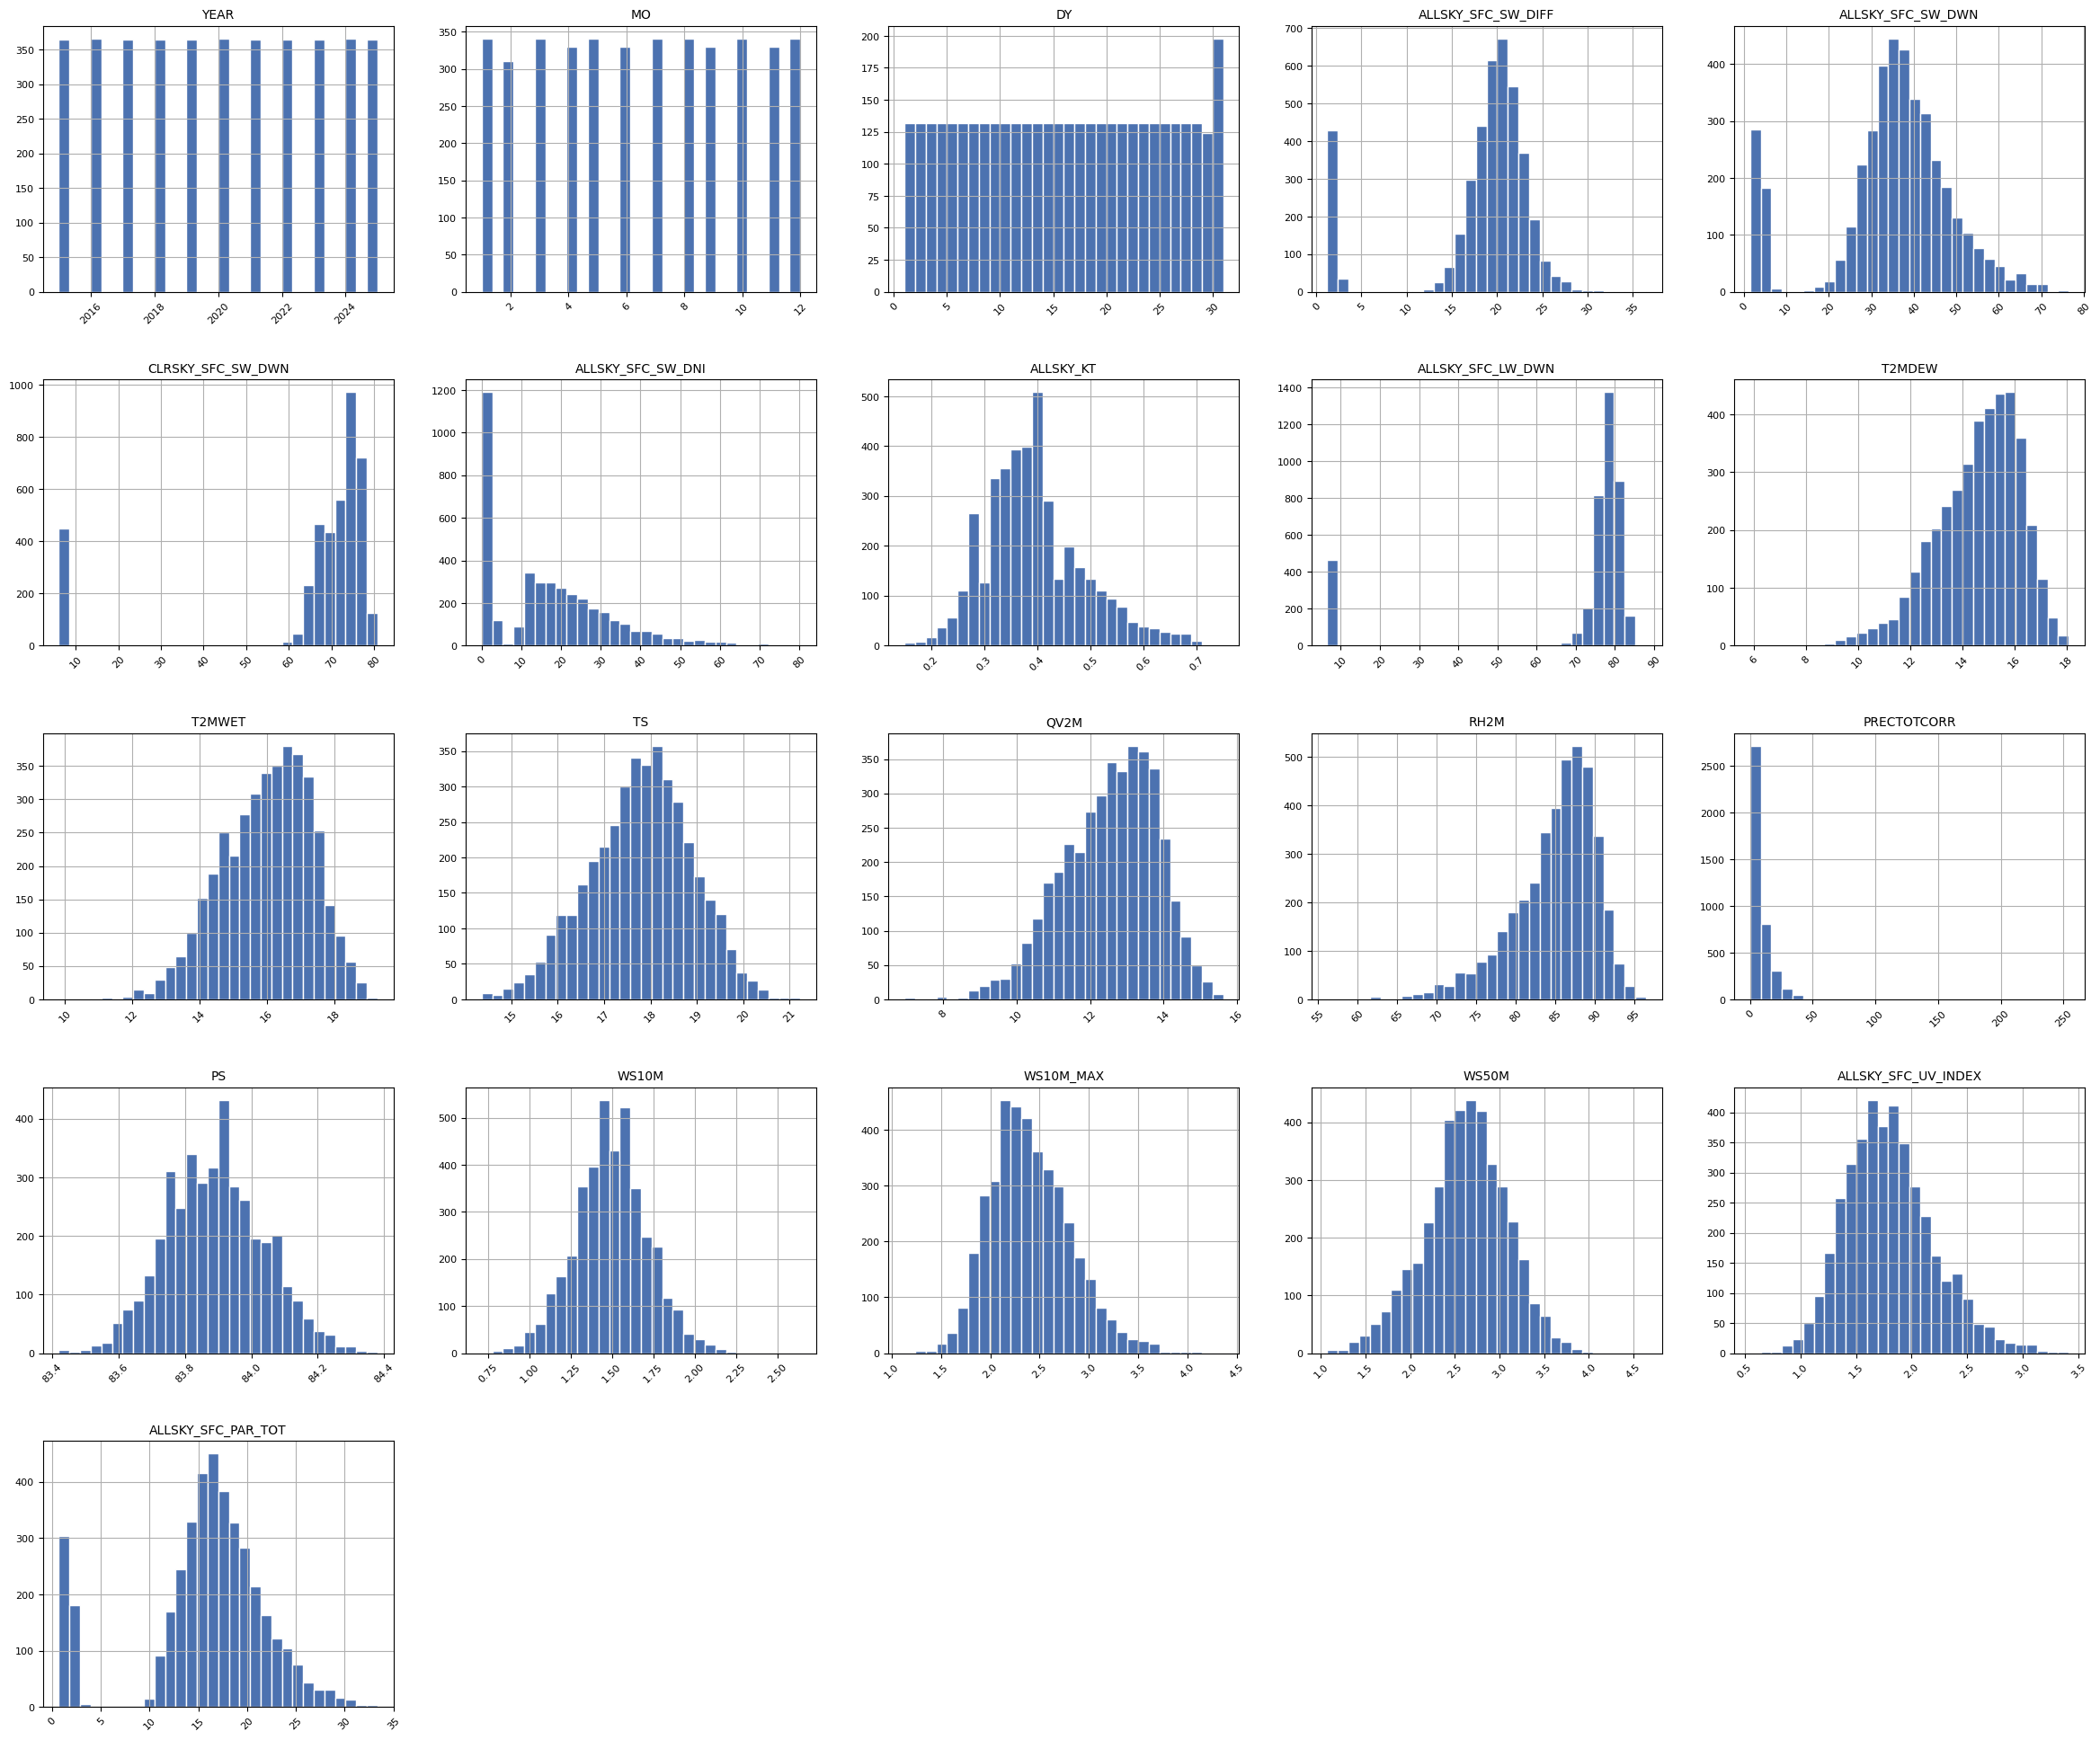

In [12]:
# Selección solo columnas numéricas
numeric_cols = df_analysis.select_dtypes(include=[np.number]).columns

# Estilo del histograma
plt.style.use("default")

fig, axes = plt.subplots(figsize=(24,20), nrows=5, ncols=5)

# Color del histograma
hist_color = "#4C72B0"

for i, col in enumerate(numeric_cols):
    ax = axes.flatten()[i]
    df_analysis[col].hist(
        ax=ax,
        bins=30,
        color=hist_color,
        edgecolor="white"
    )
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Eliminar subplots vacíos
for j in range(len(numeric_cols), len(axes.flatten())):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout(pad=3.0)
plt.show()


## Diagramas de caja de variables específicas


Se seleccionó las variables ALLSKY_SFC_SW_DWN, PRECTOTCORR, RH2M dado que se consideró claves para el estudio.

La selección se dio a tres componentes diferentes:

 * Componente de radiación (ALLSKY_SFC_SW_DWN)
 * Compoenente hidrológico (PRECTOTCORR)
 * Componente atmosférico (RH2M)

 ALLSKY_SFC_SW_DWN: Radiación solar global descente, lo que representa uno de los componentes energéticos principales por su alta relevancia en dinámica solar.

 PRECTOTCORR: Refleja variabilidad hidrometeorológica, asociada a la nubosidad y eventos extremos.

 RH2M: Humedad relativa a dos metros, siendo un indicador atmosférico de saturación lo que influye en la formación de nubes.

In [13]:
fig = px.box(
    df_analysis,
    y=["ALLSKY_SFC_SW_DWN", "PRECTOTCORR", "RH2M"],
    title="Distribución de variables seleccionadas y detección de valores atípicos",
    labels={
        "value": "Valor",
        "variable": "Variable"
    }
)

fig.update_layout(
    height=500,
    width=750,
    title_x=0.5,
    font=dict(size=11),
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show()

## Matriz de correlación

Se denota que la variable objetivo ALLSKY_SFN_SW_DIFF (Radiación difusa) presenta alta correlación y está estrechamente ligada al comportamietno general de la radiación solar con: ALLSKY_SFC_SW_DWN, ALLSKY_SFC_SW_DNI, ALLSKY_KT, ALLSKY_SFC_PAR_TOT, ALLSKY_SFC_UV_INDEX  

Con lo que respecta a las variables de temperatura y humedad se observa una fuerte correlación con T2MDEW, T2MWET, TS, QV2M, RH2M lo que muestra que existe coherencia atmosférica por lo que estas variables representan procesos termodinámicos relacionados.

Se denota que las variables WS10M, WS10M_MAX y WS50M relacionadas con el viento presetnan una correlación positiva moderada alta, es decir que tienen consistencia en dinámica eólica por lo que en diferntes alturas mantienen dependencia.

En lo que corresponde a la precipitación la variable PRECTOTCORR mantiene una correlación moderada.

La presión superficial PS muestra correlaciones negativas con humedad y temperatura, posiblemente porque cambios barométricos afectan condiciones atmosféricas.

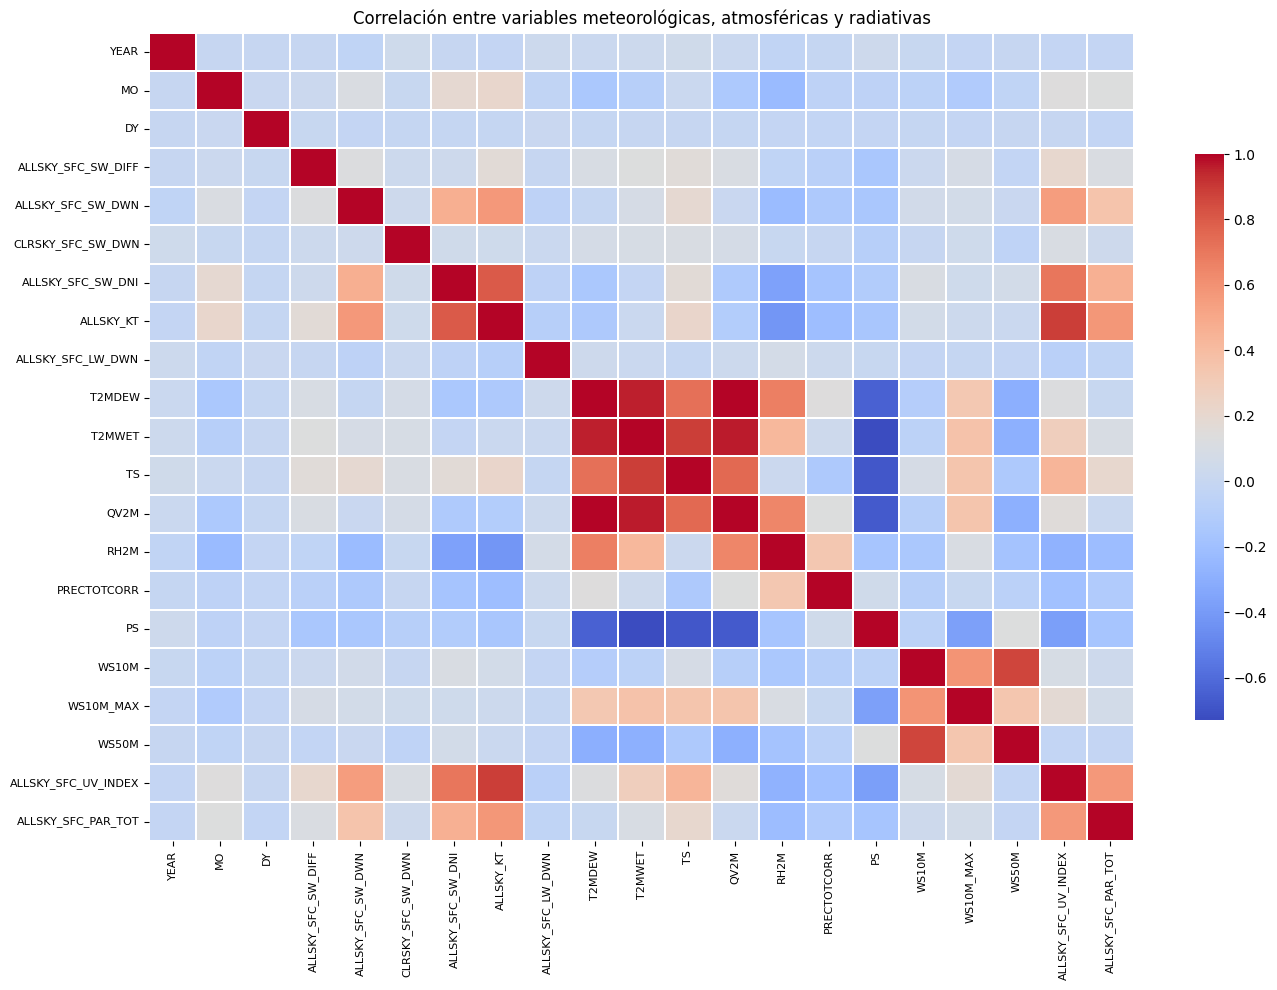

In [14]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_analysis.corr(),
    cmap="coolwarm",
    annot=False,
    linewidths=0.2,
    square=False,
    cbar_kws={"shrink": 0.7}
)

plt.title(
    "Correlación entre variables meteorológicas, atmosféricas y radiativas",
    fontsize=12
)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

## Respaldo de la base final limpia

In [16]:
df_clean = df_analysis.copy()

# Preprocesamiento y preparación de datos para el modelado predictivo

## Selección de variables en base a la matriz de correlación y relevancia en el TFM

Las variables fueron seleccionadas en base a correlaciones con la variable objetivo, relevancia física, representatividad climática y reduccipon de redundancia con el fin de asegurar estabilidad, interpretabilidad y precisión predictiva.

In [17]:
# Variable objetivo
target = "ALLSKY_SFC_SW_DIFF"

# Variables predictoras seleccionadas
selected_features = [
    "ALLSKY_SFC_SW_DWN",
    "ALLSKY_SFC_SW_DNI",
    "ALLSKY_KT",
    "ALLSKY_SFC_PAR_TOT",
    "ALLSKY_SFC_UV_INDEX",
    "RH2M",
    "T2MWET",
    "TS",
    "PRECTOTCORR",
    "WS10M"
]

# Nuevo dataset del modelado
df_model = df_clean[selected_features + [target]].copy()

print("Dimensiones del dataset para modelado:", df_model.shape)
print("\nVariables seleccionadas:")
print(df_model.columns)

Dimensiones del dataset para modelado: (4018, 11)

Variables seleccionadas:
Index(['ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DNI', 'ALLSKY_KT',
       'ALLSKY_SFC_PAR_TOT', 'ALLSKY_SFC_UV_INDEX', 'RH2M', 'T2MWET', 'TS',
       'PRECTOTCORR', 'WS10M', 'ALLSKY_SFC_SW_DIFF'],
      dtype='object')


## División de la base de datos en entrenamiento y prueba (Train/ Test)

In [18]:
# 80% entrenamiento, 20% prueba
train_size = int(len(df_model) * 0.8)

train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]

print("Train:", train.shape)
print("Test:", test.shape)

print("Periodo entrenamiento:", train.index.min(), "a", train.index.max())
print("Periodo prueba:", test.index.min(), "a", test.index.max())

Train: (3214, 11)
Test: (804, 11)
Periodo entrenamiento: 2015-01-01 00:00:00 a 2023-10-19 00:00:00
Periodo prueba: 2023-10-20 00:00:00 a 2025-12-31 00:00:00


## Normalización

In [19]:
# Escaladores independientes
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Variables predictoras
X_train = train[selected_features]
X_test = test[selected_features]

# Variable objetivo
y_train = train[[target]]
y_test = test[[target]]

# Ajuste solo con entrenamiento
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print("Escalado completado correctamente.")

Escalado completado correctamente.


## Creación de secuencias temporales para el modelo LSTM

Crear la secuencia temporal de 30 días permite capturar dependencias estacionales, tendencias de corto plazo y patrones atmosféricos recurrentes

In [20]:
def create_sequences(X, y, time_steps=30):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])

    return np.array(Xs), np.array(ys)

TIME_STEPS = 30  # 30 días

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    TIME_STEPS
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    TIME_STEPS
)

print("X_train_seq:", X_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)

X_train_seq: (3184, 30, 10)
X_test_seq: (774, 30, 10)


## Visualización Train/ Test

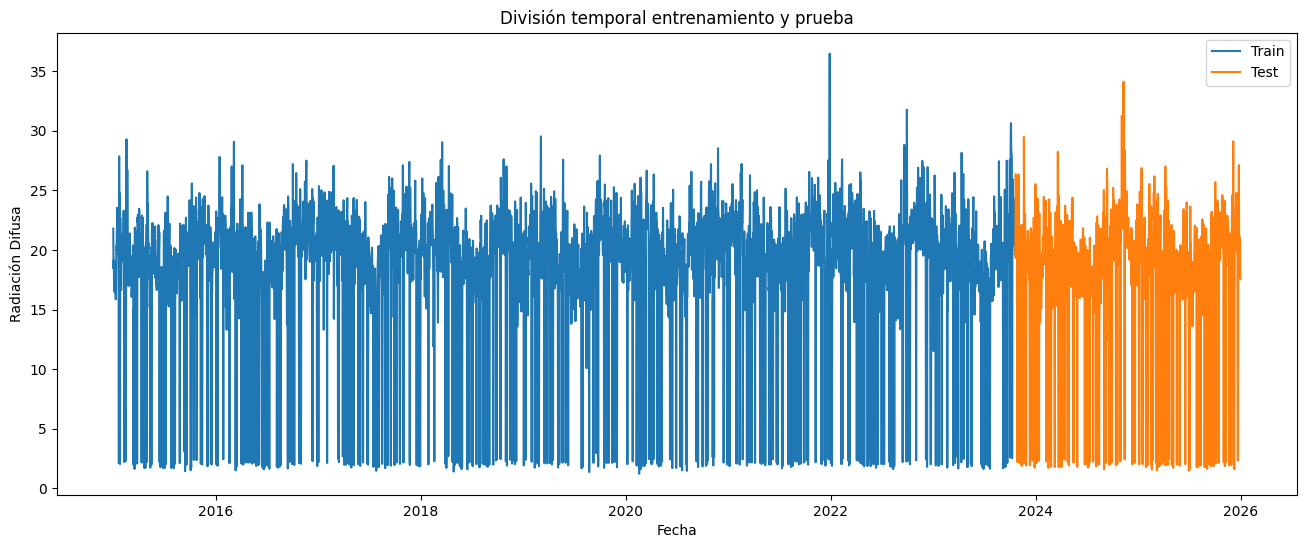

In [21]:
plt.figure(figsize=(16,6))

plt.plot(train.index, train[target], label="Train")
plt.plot(test.index, test[target], label="Test")

plt.title("División temporal entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Radiación Difusa")
plt.legend()

plt.show()

# Construcción y entrenamiento de los modelos SARIMAX, LSTM y N-BEATS

## SARIMAX

### Visualización de la serie temporal

La serie temporal de radiación difusa presenta alta variabilidad diaria durante el periodo 2015-2025.

Se observa fluctuaciones frecuentes, cambios abruptos y ausencia de un comportamiento lineal, asociadas posiblemente a la nubosidad, humedad atmosférica, precipitación y dinpamica de radiación.

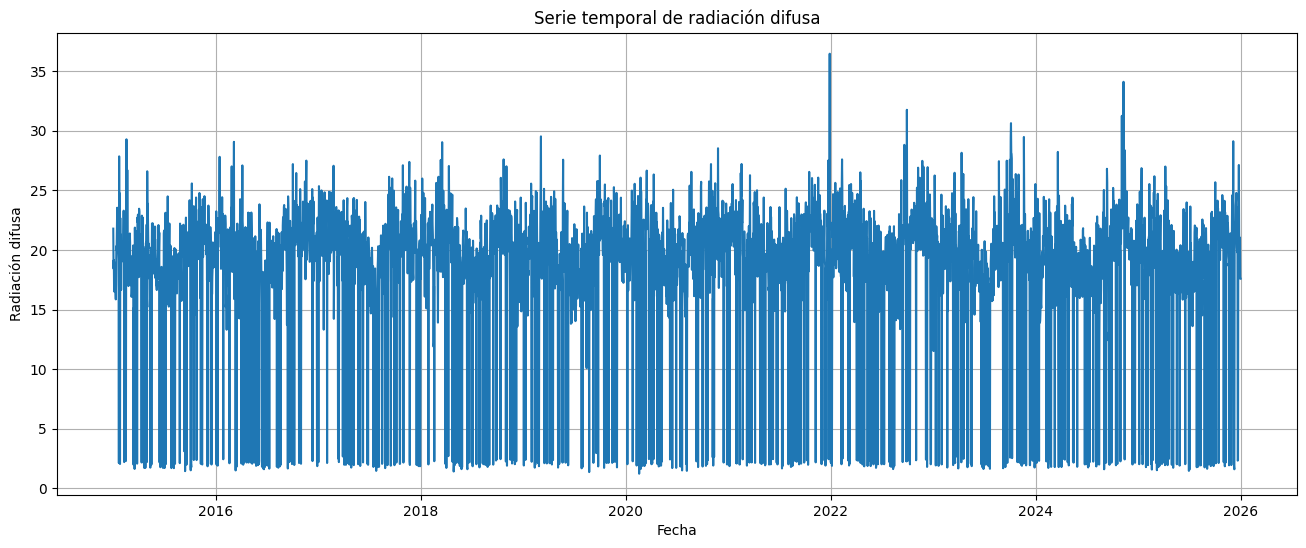

In [22]:
plt.figure(figsize=(16,6))

plt.plot(df_model.index, df_model[target])

plt.title("Serie temporal de radiación difusa")
plt.xlabel("Fecha")
plt.ylabel("Radiación difusa")

plt.grid(True)
plt.show()

### Visualización de la serie temporal con media móvil

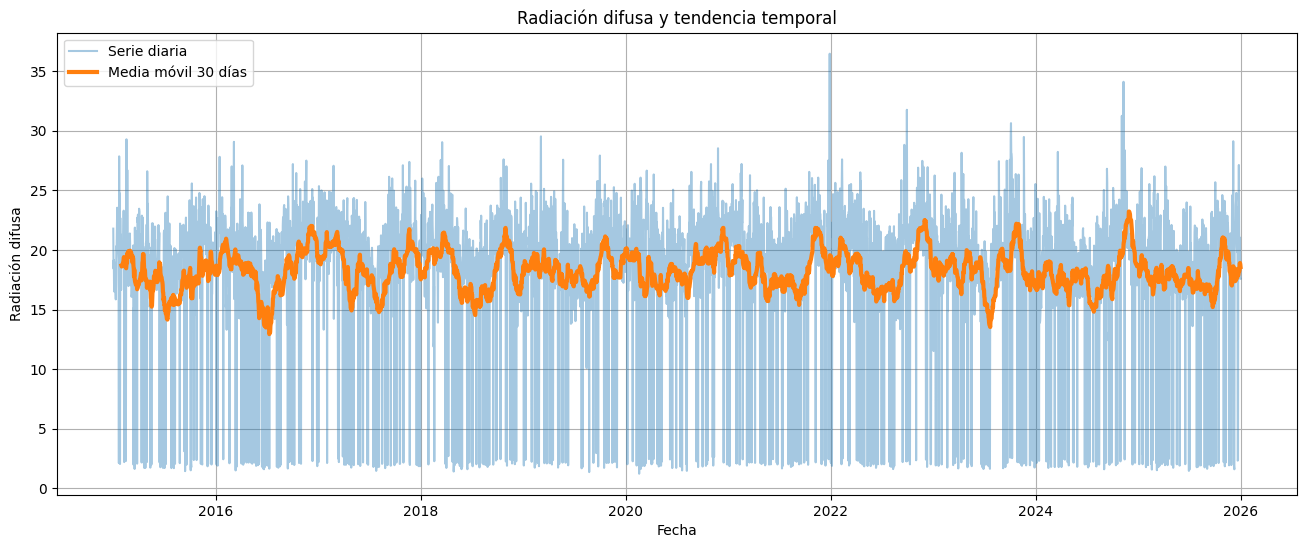

In [23]:
plt.figure(figsize=(16,6))

# Serie original
plt.plot(
    df_model.index,
    df_model[target],
    alpha=0.4,
    label="Serie diaria"
)

# Media móvil 30 días
rolling_mean = df_model[target].rolling(window=30).mean()

plt.plot(
    df_model.index,
    rolling_mean,
    linewidth=3,
    label="Media móvil 30 días"
)

plt.title("Radiación difusa y tendencia temporal")
plt.xlabel("Fecha")
plt.ylabel("Radiación difusa")

plt.legend()
plt.grid(True)

plt.show()

### Prueba de estacionariedad (ADF TEST)

La pruab de Dickey-Fuller se aplicó sobre la serie temporal de radiación difusa con el objetivo de evaluar su estacionariedad.

Se denota que el p-value es menor a 0.05 y el estadístico ADF es menor que los valores críticos, es así que se rechaza la hipótesis nula de presencia de raíz unitaria, por lo que se considera la serie temporal estacionaria, es decir que la media y varianza permanecen relativamente estables en el tiempo y no es necesario aplicar una diferenciación adicional.

In [24]:
result = adfuller(df_model[target])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nValores críticos:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic: -16.030307817068348
p-value: 6.067486016990499e-29

Valores críticos:
1% : -3.4319830157514812
5% : -2.86226157702636
10% : -2.56715410307542


### Análisis ACF Y PACF

Los gráficos ACF Y PACF permiten observar la dependencia temporal de la serie de radiación difusa, es así que se puede observar que las autocorrelaciones son bajas, la dependencia temporal disminuye rápidamente y no existen patrones persistentes de largo plazo, además la mayoría de rezagos permanece dentro de los intervalos de confianza

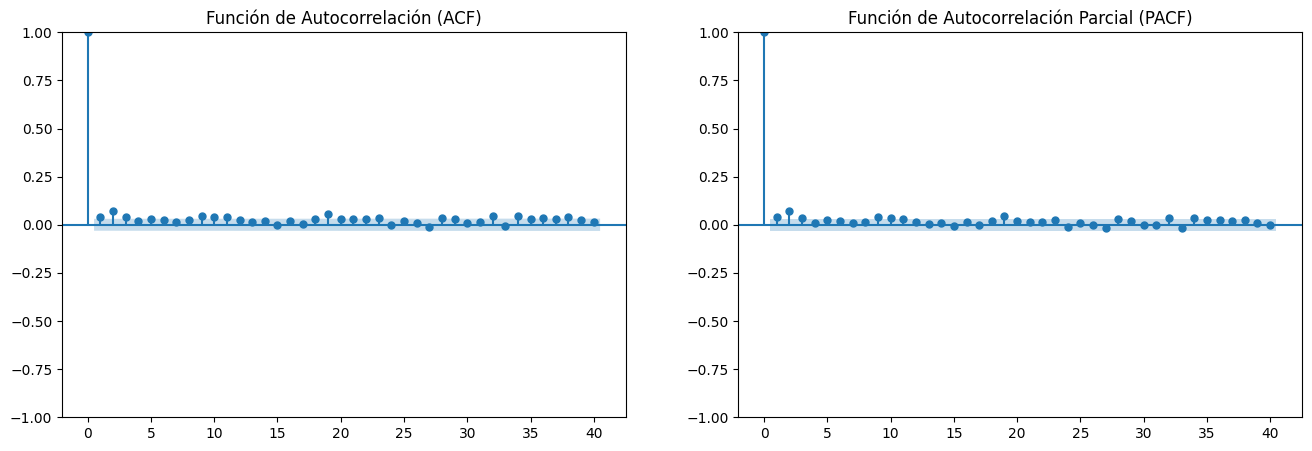

In [25]:
fig, ax = plt.subplots(1,2, figsize=(16,5))

plot_acf(df_model[target], lags=40, ax=ax[0])
plot_pacf(df_model[target], lags=40, ax=ax[1])

ax[0].set_title("Función de Autocorrelación (ACF)")
ax[1].set_title("Función de Autocorrelación Parcial (PACF)")

plt.show()

### Modelo SARIMAX

#### Modelo SARIMAX simple

El modelo fue configurado con orden =(1, 0, 1) debido a la estacionariedad confirmada, baja dependencia temporal y comportamietno autoregresivo moderado. Cade destcar que no se incorporó componenete estacional con el objetivo de evaluar el desempeño base del modelo estadístico.

In [27]:
# Construcción del modelo
model_sarimax_simple = SARIMAX(
    train[target],
    exog=train[selected_features],

    # Parámetros ARIMA
    order=(1,0,1),

    # Sin componente estacional
    seasonal_order=(0,0,0,0),

    enforce_stationarity=False,
    enforce_invertibility=False
)

# Entrenamiento
sarimax_simple_fit = model_sarimax_simple.fit(disp=False)

# Resumen estadístico
print(sarimax_simple_fit.summary())

                               SARIMAX Results                                
Dep. Variable:     ALLSKY_SFC_SW_DIFF   No. Observations:                 3214
Model:               SARIMAX(1, 0, 1)   Log Likelihood              -10340.778
Date:                Thu, 07 May 2026   AIC                          20707.557
Time:                        00:26:31   BIC                          20786.527
Sample:                    01-01-2015   HQIC                         20735.864
                         - 10-19-2023                                         
Covariance Type:                  opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
ALLSKY_SFC_SW_DWN       0.0157      0.008      1.869      0.062      -0.001       0.032
ALLSKY_SFC_SW_DNI      -0.1025      0.011     -9.723      0.000      -0.123      -0.082
ALLSKY_KT       

#### Modelo SARIMAX avanzado

Para realizar un mejor análisis se incorporó un componente estacional al modelo SARIMAX con el fin de capturar patrones periódicos presentes en la radiación difusa.
La inclusión del componente estacional permite modelar variaciones cíclicas, patrones temporales recurrentes y comportamiento atmosférico periódico.

In [29]:
model_sarimax_advanced = SARIMAX(
    train[target],
    exog=train[selected_features],

    # Modelo principal
    order=(1,0,1),

    # Componente estacional anual
    seasonal_order=(1,0,1,30),

    enforce_stationarity=False,
    enforce_invertibility=False
)

# Entrenamiento
sarimax_advanced_fit = model_sarimax_advanced.fit(disp=False)

# Resumen
print(sarimax_advanced_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                 ALLSKY_SFC_SW_DIFF   No. Observations:                 3214
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 30)   Log Likelihood              -10248.374
Date:                            Thu, 07 May 2026   AIC                          20526.748
Time:                                    00:39:31   BIC                          20617.727
Sample:                                01-01-2015   HQIC                         20559.375
                                     - 10-19-2023                                         
Covariance Type:                              opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
ALLSKY_SFC_SW_DWN       0.0152      0.008      1.787      0.074      -0.001       0.032
ALLSKY_S

### Predicciones modelo SARIMAX

Se realizó predicciones sobre el conjunto de prueba utilizando el modelo SARIMAX avanzado, dado que las predicciones permiten evaluar la capacidad del modelo para reproducir patrones temporales, capturar variaciones atmosféricas y estimar valores futuros de la radiación difusa

In [36]:
# Predicciones
sarimax_adv_pred = sarimax_advanced_fit.predict(
    start=test.index[0],
    end=test.index[-1],
    exog=test[selected_features]
)

# Visualizar primeras predicciones
print(sarimax_adv_pred.head())

2023-10-20    18.148106
2023-10-21    18.018028
2023-10-22    21.183287
2023-10-23    19.855181
2023-10-24    20.327527
Freq: D, Name: predicted_mean, dtype: float64


### Evaluación modelo SARIMAX

In [38]:
# MAE
mae_sarimax_adv = mean_absolute_error(
    test[target],
    sarimax_adv_pred
)

# RMSE
rmse_sarimax_adv = np.sqrt(
    mean_squared_error(
        test[target],
        sarimax_adv_pred
    )
)

# R²
r2_sarimax_adv = r2_score(
    test[target],
    sarimax_adv_pred
)

# Mostrar resultados
print("========== MÉTRICAS SARIMAX ==========")

print(f"MAE  : {mae_sarimax_adv:.4f}")
print(f"RMSE : {rmse_sarimax_adv:.4f}")
print(f"R²   : {r2_sarimax_adv:.4f}")

========== MÉTRICAS SARIMAX ==========
MAE  : 3.9703
RMSE : 6.3755
R²   : 0.0672


### Visualización Real vs Predicción

###

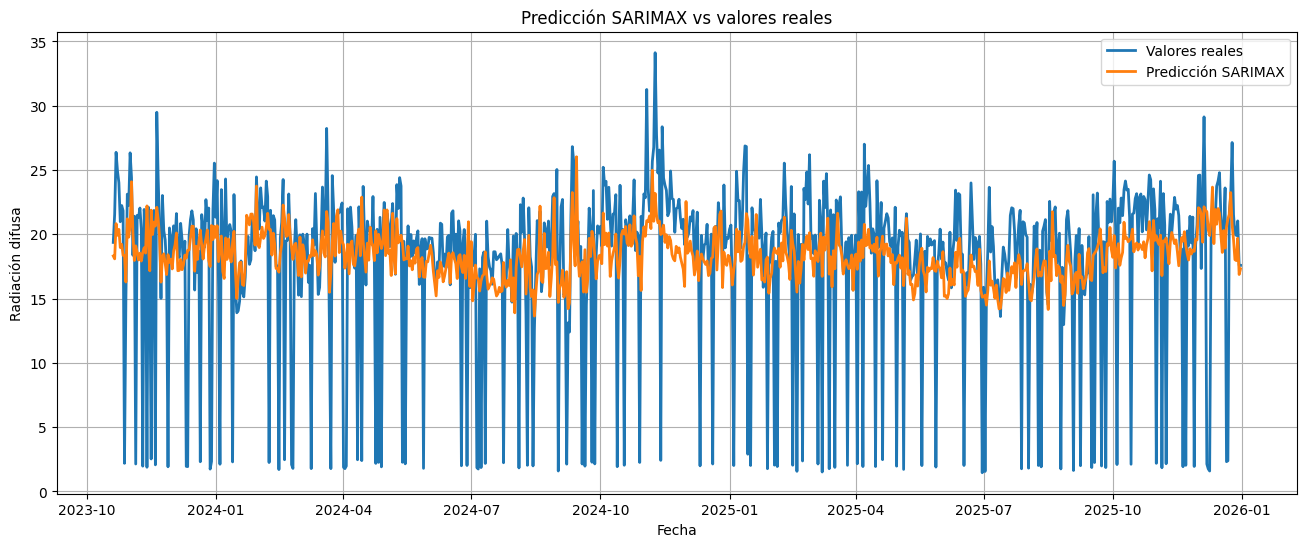

In [46]:

plt.figure(figsize=(16,6))

# Valores reales
plt.plot(
    test.index,
    test[target],
    label="Valores reales",
    linewidth=2
)

# Predicciones SARIMAX
plt.plot(
    test.index,
    sarimax_pred,
    label="Predicción SARIMAX",
    linewidth=2
)

plt.title("Predicción SARIMAX vs valores reales")

plt.xlabel("Fecha")
plt.ylabel("Radiación difusa")

plt.legend()
plt.grid(True)

plt.show()

### Residuos del modelo

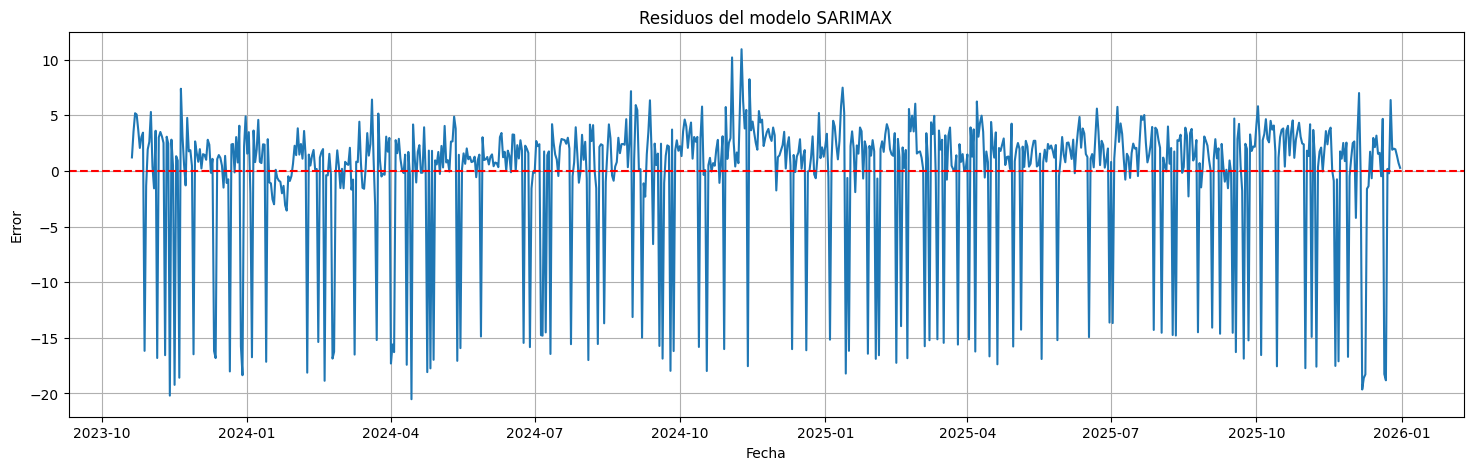

In [43]:
# Residuos
residuals_adv = test[target] - sarimax_adv_pred

# Gráfico
plt.figure(figsize=(18,5))

plt.plot(
    test.index,
    residuals_adv
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residuos del modelo SARIMAX")

plt.xlabel("Fecha")
plt.ylabel("Error")

plt.grid(True)

plt.show()

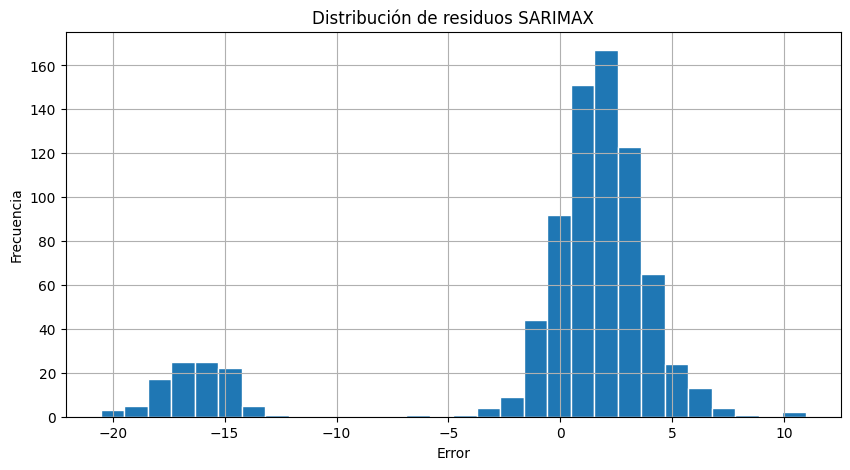

In [45]:
plt.figure(figsize=(10,5))

plt.hist(
    residuals_adv,
    bins=30,
    edgecolor='white'
)

plt.title("Distribución de residuos SARIMAX")

plt.xlabel("Error")
plt.ylabel("Frecuencia")

plt.grid(True)

plt.show()

## LSTM

### Selección de variables

In [47]:
#Variables predictoras
selected_features = [
    "ALLSKY_SFC_SW_DWN",
    "ALLSKY_SFC_SW_DNI",
    "ALLSKY_KT",
    "ALLSKY_SFC_UV_INDEX",
    "RH2M",
    "T2MWET",
    "TS",
    "PRECTOTCORR",
    "WS10M"
]

In [48]:
#Variable objetivo
target = "ALLSKY_SFC_SW_DIFF"

### Normalización de variables

In [49]:

# Variables de entrada + target
features_lstm = selected_features + [target]

# Dataset para LSTM
df_lstm = df_clean[features_lstm].copy()

# Escalador
scaler = MinMaxScaler()

# Normalización
scaled_data = scaler.fit_transform(df_lstm)

# Convertimos nuevamente a DataFrame
scaled_df = pd.DataFrame(
    scaled_data,
    columns=features_lstm,
    index=df_lstm.index
)

# Verificación
print(scaled_df.head())

            ALLSKY_SFC_SW_DWN  ALLSKY_SFC_SW_DNI  ALLSKY_KT  \
fecha                                                         
2015-01-01           0.542425           0.297537   0.450000   
2015-01-02           0.431176           0.202958   0.316667   
2015-01-03           0.433297           0.019803   0.316667   
2015-01-04           0.326784           0.007134   0.183333   
2015-01-05           0.412288           0.167134   0.283333   

            ALLSKY_SFC_UV_INDEX      RH2M    T2MWET        TS  PRECTOTCORR  \
fecha                                                                        
2015-01-01             0.517483  0.723916  0.633580  0.493450     0.007002   
2015-01-02             0.395105  0.765304  0.623020  0.464338     0.004209   
2015-01-03             0.384615  0.825527  0.567054  0.331878     0.010778   
2015-01-04             0.290210  0.753903  0.484688  0.245997     0.021321   
2015-01-05             0.360140  0.722181  0.536431  0.378457     0.009441   

           

### Creación de secuencias temporales para el modelo LSTM creado en el apartado de preprocesamiento

In [50]:
def create_sequences(X, y, time_steps=30):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])

    return np.array(Xs), np.array(ys)

TIME_STEPS = 30  # 30 días

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    TIME_STEPS
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    TIME_STEPS
)

print("X_train_seq:", X_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)

X_train_seq: (3184, 30, 10)
X_test_seq: (774, 30, 10)


Construcción del modelo LSTM

In [52]:
model_lstm = Sequential()

# Primera capa LSTM


model_lstm.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    )
)

# Regularización Dropout
model_lstm.add(Dropout(0.2))


# Segunda capa LSTM


model_lstm.add(
    LSTM(
        units=32,
        return_sequences=False
    )
)

# Regularización Dropout
model_lstm.add(Dropout(0.2))

#Capa de salida

model_lstm.add(Dense(1))

#Compilación del modelo

model_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

#Resumen del modelo

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo LSTM

In [54]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

#Entrenamiento
history = model_lstm.fit(

    X_train_seq,
    y_train_seq,

    epochs=100,
    batch_size=32,

    validation_split=0.2,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0424 - mae: 0.1505 - val_loss: 0.0308 - val_mae: 0.1086
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0356 - mae: 0.1337 - val_loss: 0.0313 - val_mae: 0.1285
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0353 - mae: 0.1317 - val_loss: 0.0312 - val_mae: 0.1277
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0338 - mae: 0.1286 - val_loss: 0.0308 - val_mae: 0.1063
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0341 - mae: 0.1282 - val_loss: 0.0304 - val_mae: 0.1145
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0344 - mae: 0.1300 - val_loss: 0.0306 - val_mae: 0.1079
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0338 - mae: 0.1284 - val_loss: 0.0304 - val_mae: 0.1126
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0341 - mae: 0.1286 - val_loss: 0.0325 - val_mae: 0.1389
Epoch 9/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - lo

### Curvas de entrenamiento

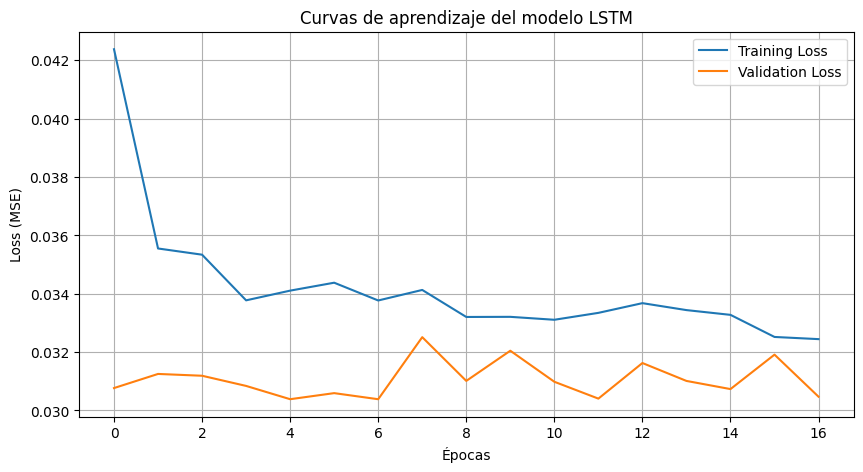

In [55]:
plt.figure(figsize=(10,5))

# Loss entrenamiento
plt.plot(
    history.history['loss'],
    label='Training Loss'
)

# Loss validación
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Curvas de aprendizaje del modelo LSTM")

plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")

plt.legend()

plt.grid(True)

plt.show()

### Predicciones del modelo LSTM normalizadas

In [56]:
# Predicciones normalizadas
y_pred_lstm_scaled = model_lstm.predict(X_test_seq)

print(y_pred_lstm_scaled[:5])

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
[[0.5435929 ]
 [0.54991794]
 [0.5547624 ]
 [0.5581727 ]
 [0.5569727 ]]


### Predicciones del modelo LSTM desnormalizadas

In [57]:

# Valores reales
y_test_real = scaler_y.inverse_transform(
    y_test_seq.reshape(-1,1)
)

# Predicciones reales
y_pred_real = scaler_y.inverse_transform(
    y_pred_lstm_scaled
)

# Mostrar primeras predicciones reales
print("Predicciones reales:")
print(y_pred_real[:5])

Predicciones reales:
[[20.385084]
 [20.608107]
 [20.778923]
 [20.89917 ]
 [20.856857]]


### Evaluación modelo LSTM

In [58]:
# Métricas
mae_lstm = mean_absolute_error(
    y_test_real,
    y_pred_real
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        y_test_real,
        y_pred_real
    )
)

r2_lstm = r2_score(
    y_test_real,
    y_pred_real
)

#Resultados
print("========== MÉTRICAS LSTM ==========")

print(f"MAE  : {mae_lstm:.4f}")
print(f"RMSE : {rmse_lstm:.4f}")
print(f"R²   : {r2_lstm:.4f}")

========== MÉTRICAS LSTM ==========
MAE  : 4.0472
RMSE : 6.6262
R²   : -0.0213


## N-BEATS

### Base de datos para N-BEATS

In [61]:
# Variable objetivo
target = "ALLSKY_SFC_SW_DIFF"

# Dataset exclusivo para N-BEATS
df_nbeats = df_clean[[target]].copy()

# Visualización
print(df_nbeats.head())

print("\nDimensiones:")
print(df_nbeats.shape)

            ALLSKY_SFC_SW_DIFF
fecha                         
2015-01-01              21.794
2015-01-02              18.437
2015-01-03              19.157
2015-01-04              16.519
2015-01-05              18.482

Dimensiones:
(4018, 1)


### Creación de serie temporal

In [62]:
from darts import TimeSeries

series = TimeSeries.from_dataframe(
    df_nbeats,
    value_cols=target
)

print(series)

<TimeSeries (DataArray) (fecha: 4018, component: 1, sample: 1)> Size: 32kB
array([[[21.794]],

       [[18.437]],

       [[19.157]],

       ...,

       [[21.041]],

       [[17.585]],

       [[17.585]]])
Coordinates:
  * fecha      (fecha) datetime64[ns] 32kB 2015-01-01 2015-01-02 ... 2025-12-31
  * component  (component) object 8B 'ALLSKY_SFC_SW_DIFF'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None


### Base de datos de entrenamiento y test (Train/Test)

In [63]:
train_size = int(len(series) * 0.8)

train_series = series[:train_size]

test_series = series[train_size:]

print("Train:", len(train_series))

print("Test:", len(test_series))

Train: 3214
Test: 804


### Normalización

In [64]:
from darts.dataprocessing.transformers import Scaler

# Escalador
scaler_nbeats = Scaler()

# Ajuste y transformación
train_scaled = scaler_nbeats.fit_transform(
    train_series
)

# Transformación test
test_scaled = scaler_nbeats.transform(
    test_series
)

print(train_scaled)

<TimeSeries (DataArray) (fecha: 3214, component: 1, sample: 1)> Size: 26kB
array([[[0.58355077]],

       [[0.48834373]],

       [[0.50876347]],

       ...,

       [[0.62963698]],

       [[0.57674419]],

       [[0.52291548]]])
Coordinates:
  * fecha      (fecha) datetime64[ns] 26kB 2015-01-01 2015-01-02 ... 2023-10-19
  * component  (component) object 8B 'ALLSKY_SFC_SW_DIFF'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None


### Entrenamiento del modelo N-BEATS

In [65]:
# Modelo
model_nbeats = NBEATSModel(

    input_chunk_length=30,
    output_chunk_length=1,

    n_epochs=100,

    batch_size=32,

    num_stacks=10,
    num_blocks=1,
    num_layers=4,
    layer_widths=256,

    random_state=42
)

# Entrenamiento
model_nbeats.fit(train_scaled)

print("Modelo N-BEATS entrenado correctamente")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ stacks          │ ModuleList       │  2.1 M │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 1.5 K                                                                                        
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 16                                                                         
Modules in train mode: 136                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


Modelo N-BEATS entrenado correctamente


### Predicciones del modelo N-BEATS normalizadas

In [66]:
forecast_scaled = model_nbeats.predict(
    n=len(test_scaled)
)

print(forecast_scaled)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

<TimeSeries (DataArray) (fecha: 804, component: 1, sample: 1)> Size: 6kB
array([[[0.58446452]],

       [[0.53550379]],

       [[0.57951753]],

       [[0.67201438]],

       [[0.53088434]],

       [[0.36604977]],

       [[0.50932437]],

       [[0.4670748 ]],

       [[0.55655325]],

       [[0.47814046]],

...

       [[0.43844502]],

       [[0.14402189]],

       [[0.41739555]],

       [[0.08841455]],

       [[0.44725374]],

       [[0.40436084]],

       [[0.44792006]],

       [[0.42881497]],

       [[0.45870284]],

       [[0.43997832]]])
Coordinates:
  * fecha      (fecha) datetime64[ns] 6kB 2023-10-20 2023-10-21 ... 2025-12-31
  * component  (component) object 8B 'ALLSKY_SFC_SW_DIFF'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None


### Predicciones del modelo N-BEATS desnormalizadas

In [67]:
forecast = scaler_nbeats.inverse_transform(
    forecast_scaled
)

print(forecast)

<TimeSeries (DataArray) (fecha: 804, component: 1, sample: 1)> Size: 6kB
array([[[21.82621907]],

       [[20.09986351]],

       [[21.65178804]],

       [[24.91322712]],

       [[19.93698189]],

       [[14.1249149 ]],

       [[19.17677727]],

       [[17.68705747]],

       [[20.8420675 ]],

       [[18.07723259]],

...

       [[16.67757141]],

       [[ 6.29621176]],

       [[15.93536715]],

       [[ 4.33549704]],

       [[16.98816682]],

       [[15.47576329]],

       [[17.01166143]],

       [[16.33801589]],

       [[17.39186223]],

       [[16.7316356 ]]])
Coordinates:
  * fecha      (fecha) datetime64[ns] 6kB 2023-10-20 2023-10-21 ... 2025-12-31
  * component  (component) object 8B 'ALLSKY_SFC_SW_DIFF'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None


### Evaluación del modelo N-BEATS

In [68]:
# Valores reales
y_true_nbeats = test_series.values().flatten()

# Predicciones
y_pred_nbeats = forecast.values().flatten()

# Métricas

mae_nbeats = mean_absolute_error(
    y_true_nbeats,
    y_pred_nbeats
)

rmse_nbeats = np.sqrt(
    mean_squared_error(
        y_true_nbeats,
        y_pred_nbeats
    )
)

r2_nbeats = r2_score(
    y_true_nbeats,
    y_pred_nbeats
)

#Resultados

print("========== MÉTRICAS N-BEATS ==========")

print(f"MAE  : {mae_nbeats:.4f}")

print(f"RMSE : {rmse_nbeats:.4f}")

print(f"R²   : {r2_nbeats:.4f}")

========== MÉTRICAS N-BEATS ==========
MAE  : 6.3693
RMSE : 8.0636
R²   : -0.4922


# Comparación de los modelos SARIMAX, LSTM y N-BEATS

In [69]:
comparison_final = pd.DataFrame({

    "Modelo": [
        "SARIMAX",
        "LSTM",
        "N-BEATS"
    ],

    "MAE": [
        mae_sarimax,
        mae_lstm,
        mae_nbeats
    ],

    "RMSE": [
        rmse_sarimax,
        rmse_lstm,
        rmse_nbeats
    ],

    "R2": [
        r2_sarimax,
        r2_lstm,
        r2_nbeats
    ]

})

print("========== COMPARACIÓN MODELOS ==========")

print(comparison_final)

========== COMPARACIÓN MODELOS ==========
    Modelo       MAE      RMSE        R2
0  SARIMAX  3.967800  6.376719  0.066807
1     LSTM  4.047199  6.626213 -0.021347
2  N-BEATS  6.369294  8.063580 -0.492220
